In [ ]:
import pandas as pd
import numpy as np
from sqlalchemy import create_engine
import os
from dotenv import load_dotenv
import matplotlib.pyplot as plt
import seaborn as sns 

In [ ]:
load_dotenv("../.env")

DB_USER = os.getenv("DB_USER")
DB_PASS = os.getenv("DB_PASSWORD")
DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")
DB_NAME = os.getenv("DB_NAME")

DATABASE_URL = f"postgresql://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}"

engine = create_engine(DATABASE_URL)
df = pd.read_sql("SELECT * FROM ames_housing_project", engine)
df.head()

,order_id,pid,ms_subclass,ms_zoning,lot_frontage,lot_area,street,alley,lot_shape,land_contour,...,pool_area,pool_qc,fence,misc_feature,misc_val,mo_sold,yr_sold,sale_type,sale_condition,sale_price
0,1,526301100,20,RL,141.0,31770,Pave,NA,IR1,Lvl,...,0,NA,NA,NA,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NA,Reg,Lvl,...,0,NA,MnPrv,NA,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NA,IR1,Lvl,...,0,NA,NA,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NA,Reg,Lvl,...,0,NA,NA,NA,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NA,IR1,Lvl,...,0,NA,MnPrv,NA,0,3,2010,WD,Normal,189900


In [ ]:
df = df.drop(columns = ['order_id','pid'])

In [ ]:
df.head()

,ms_subclass,ms_zoning,lot_frontage,lot_area,street,alley,lot_shape,land_contour,utilities,lot_config,...,pool_area,pool_qc,fence,misc_feature,misc_val,mo_sold,yr_sold,sale_type,sale_condition,sale_price
0,20,RL,141.0,31770,Pave,NA,IR1,Lvl,AllPub,Corner,...,0,NA,NA,NA,0,5,2010,WD,Normal,215000
1,20,RH,80.0,11622,Pave,NA,Reg,Lvl,AllPub,Inside,...,0,NA,MnPrv,NA,0,6,2010,WD,Normal,105000
2,20,RL,81.0,14267,Pave,NA,IR1,Lvl,AllPub,Corner,...,0,NA,NA,Gar2,12500,6,2010,WD,Normal,172000
3,20,RL,93.0,11160,Pave,NA,Reg,Lvl,AllPub,Corner,...,0,NA,NA,NA,0,4,2010,WD,Normal,244000
4,60,RL,74.0,13830,Pave,NA,IR1,Lvl,AllPub,Inside,...,0,NA,MnPrv,NA,0,3,2010,WD,Normal,189900


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 80 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ms_subclass      2930 non-null   int64  
 1   ms_zoning        2930 non-null   str    
 2   lot_frontage     2440 non-null   float64
 3   lot_area         2930 non-null   int64  
 4   street           2930 non-null   str    
 5   alley            2930 non-null   str    
 6   lot_shape        2930 non-null   str    
 7   land_contour     2930 non-null   str    
 8   utilities        2930 non-null   str    
 9   lot_config       2930 non-null   str    
 10  land_slope       2930 non-null   str    
 11  neighborhood     2930 non-null   str    
 12  condition_1      2930 non-null   str    
 13  condition_2      2930 non-null   str    
 14  bldg_type        2930 non-null   str    
 15  house_style      2930 non-null   str    
 16  overall_qual     2930 non-null   int64  
 17  overall_cond     2930 non

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isna().sum().sum()

np.int64(719)

In [ ]:
null_counts = df.isna().sum()

print(null_counts[null_counts > 0])

lot_frontage       490
mas_vnr_type        23
mas_vnr_area        23
bsmt_qual            1
bsmt_cond            1
bsmt_exposure        4
bsmt_fin_type_1      1
bsmt_fin_sf_1        1
bsmt_fin_type_2      2
bsmt_fin_sf_2        1
bsmt_unf_sf          1
total_bsmt_sf        1
electrical           1
bsmt_full_bath       2
bsmt_half_bath       2
garage_yr_blt      159
garage_finish        2
garage_cars          1
garage_area          1
garage_qual          1
garage_cond          1
dtype: int64


In [ ]:
garage_cols = [col for col in df.columns if 'garage' in col]

garage_analysis = df[df['garage_yr_blt'].isnull()][garage_cols]

print(garage_analysis.head(10))

    garage_type  garage_yr_blt garage_finish  garage_cars  garage_area  \
27           NA            NaN            NA          0.0          0.0   
119          NA            NaN            NA          0.0          0.0   
125          NA            NaN            NA          0.0          0.0   
129          NA            NaN            NA          0.0          0.0   
130          NA            NaN            NA          0.0          0.0   
170          NA            NaN            NA          0.0          0.0   
171          NA            NaN            NA          0.0          0.0   
186          NA            NaN            NA          0.0          0.0   
203          NA            NaN            NA          0.0          0.0   
206          NA            NaN            NA          0.0          0.0   

    garage_qual garage_cond  
27           NA          NA  
119          NA          NA  
125          NA          NA  
129          NA          NA  
130          NA          NA  
170  

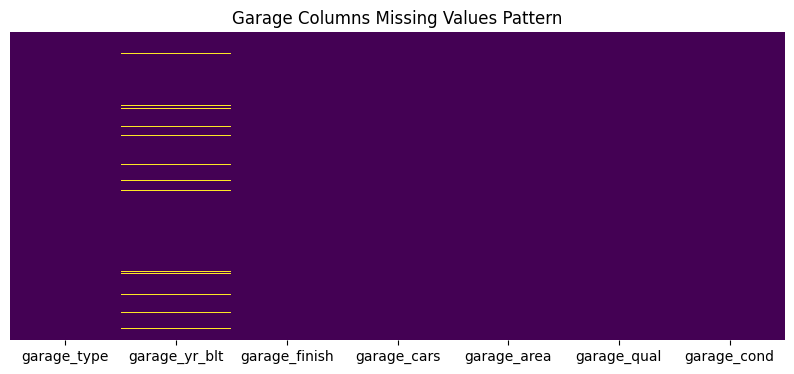

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
sns.heatmap(df[garage_cols].isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title("Garage Columns Missing Values Pattern")
plt.show()

In [ ]:
df.drop('garage_yr_blt', axis=1, inplace=True)

garage_info = df.filter(like='garage').columns
print(garage_info)

Index(['garage_type', 'garage_finish', 'garage_cars', 'garage_area',
       'garage_qual', 'garage_cond'],
      dtype='str')


In [ ]:
garage_num_cols = df.filter(like='garage').select_dtypes(include='number').columns
df[garage_num_cols] = df[garage_num_cols].fillna(0)

In [ ]:
garage_cat_cols = df.filter(like='garage').select_dtypes(include=['object', 'str']).columns
df[garage_cat_cols] = df[garage_cat_cols].fillna('None')

In [ ]:
bsmt_cols = [col for col in df.columns if 'bsmt' in col]

bsmt_analysis = df[df['bsmt_qual'].isnull()][bsmt_cols]

print(bsmt_analysis.head(10))

     bsmt_qual bsmt_cond bsmt_exposure bsmt_fin_type_1  bsmt_fin_sf_1  \
1341       NaN       NaN           NaN             NaN            NaN   

     bsmt_fin_type_2  bsmt_fin_sf_2  bsmt_unf_sf  total_bsmt_sf  \
1341             NaN            NaN          NaN            NaN   

      bsmt_full_bath  bsmt_half_bath  
1341             NaN             NaN  


In [ ]:
bsmt_num_cols = df.filter(like='bsmt').select_dtypes(include=['number']).columns
df[bsmt_num_cols] = df[bsmt_num_cols].fillna(0)

In [ ]:
bsmt_cat_cols = df.filter(like='bsmt').select_dtypes(include=['object','str']).columns
df[bsmt_cat_cols] = df[bsmt_cat_cols].fillna('None')

In [ ]:
df['electrical'] = df['electrical'].fillna(df['electrical'].mode()[0])

In [ ]:
df['mas_vnr_area'] = df['mas_vnr_area'].fillna(0)

In [ ]:
df['mas_vnr_type'] = df['mas_vnr_type'].fillna('None')

In [ ]:
lot_frontage_analysis = df[df['lot_frontage'].isnull()]['neighborhood']

print(lot_frontage_analysis.head(10))

11    Gilbert
14    StoneBr
22    Somerst
23      NAmes
24      NAmes
55    Gilbert
57    Gilbert
58    Gilbert
74    SawyerW
79    SawyerW
Name: neighborhood, dtype: str


In [ ]:
df['lot_frontage'] = df.groupby('neighborhood')['lot_frontage'].transform(lambda val: val.fillna(val.mean()))

In [ ]:
df['lot_frontage'] = df['lot_frontage'].fillna(df['lot_frontage'].mean())

In [ ]:
df.isna().sum().sum()

np.int64(0)

In [ ]:
df['house_age'] = df['yr_sold'] - df['year_built']  
df['total_living_area'] = df['first_flr_sf'] + df['second_flr_sf'] + df['total_bsmt_sf']
df['is_remoded'] = (df['year_built'] != df['year_remod_add']).astype(int)
df['total_bathrooms'] = df['full_bath'] + df['half_bath'] * 0.5 + df['bsmt_full_bath'] + df['bsmt_half_bath'] * 0.5 

In [ ]:
cols_to_drop = [
    'year_remod_add', 
    'first_flr_sf', 'second_flr_sf', 'total_bsmt_sf', 
    'full_bath', 'half_bath', 'bsmt_full_bath', 'bsmt_half_bath' 
]

df = df.drop(columns=cols_to_drop)

In [ ]:
df.describe()

,ms_subclass,lot_frontage,lot_area,overall_qual,overall_cond,year_built,mas_vnr_area,bsmt_fin_sf_1,bsmt_fin_sf_2,bsmt_unf_sf,...,screen_porch,pool_area,misc_val,mo_sold,yr_sold,sale_price,house_age,total_living_area,is_remoded,total_bathrooms
count,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,...,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000
mean,57.387372,69.883115,10147.921843,6.094881,5.563140,1971.356314,101.096928,442.478498,49.705461,559.071672,...,16.002048,2.243345,50.635154,6.216041,2007.790444,180796.060068,36.434130,2546.269283,0.464505,2.217918
std,42.638025,21.735515,7880.017759,1.411026,1.111537,30.245361,178.634545,455.586452,169.142089,439.540571,...,56.087370,35.597181,566.344288,2.714492,1.316613,79886.692357,30.291357,804.350838,0.498824,0.807444
min,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,2006.000000,12789.000000,-1.000000,334.000000,0.000000,1.000000
25%,20.000000,60.000000,7440.250000,5.000000,5.000000,1954.000000,0.000000,0.000000,0.000000,219.000000,...,0.000000,0.000000,0.000000,4.000000,2007.000000,129500.000000,7.000000,2000.000000,0.000000,1.500000
50%,50.000000,70.000000,9436.500000,6.000000,5.000000,1973.000000,0.000000,370.000000,0.000000,465.500000,...,0.000000,0.000000,0.000000,6.000000,2008.000000,160000.000000,34.000000,2450.000000,0.000000,2.000000
75%,70.000000,80.000000,11555.250000,7.000000,6.000000,2001.000000,162.750000,734.000000,0.000000,801.750000,...,0.000000,0.000000,0.000000,8.000000,2009.000000,213500.000000,54.000000,2990.000000,1.000000,2.500000
max,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,1600.000000,5644.000000,1526.000000,2336.000000,...,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000,136.000000,11752.000000,1.000000,7.000000


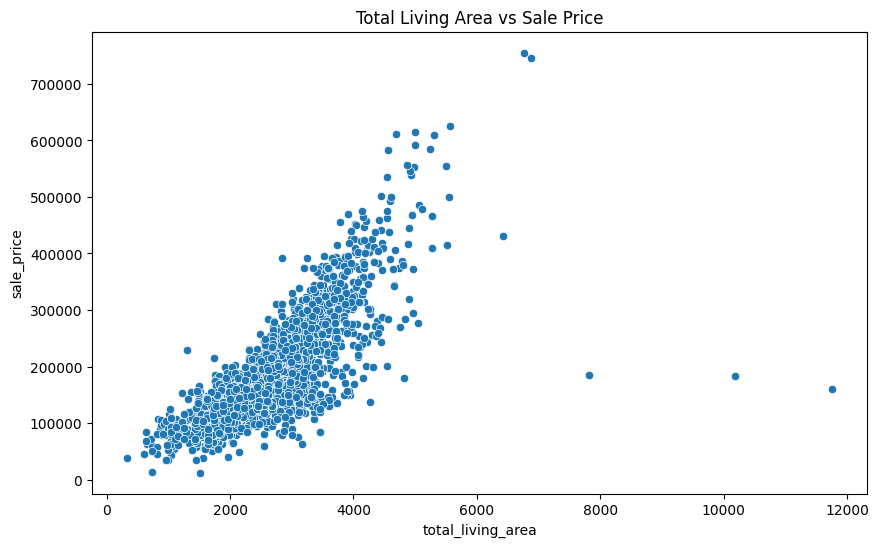

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='total_living_area', y='sale_price')
plt.title('Total Living Area vs Sale Price')
plt.show()

In [ ]:
outlier_indices = df[(df['total_living_area'] > 5000) & (df['sale_price'] < 400000)].index
df = df.drop(outlier_indices, axis=0)

print(len(outlier_indices))

4


In [ ]:
numeric_cols = df.select_dtypes(include=['number']).columns

true_continuous = []

for col in numeric_cols:
    if df[col].dtype == 'float64' or df[col].nunique() > 25:
        true_continuous.append(col)

outlier_counts = {}

for col in true_continuous:
    if (df[col].value_counts(normalize=True).iloc[0] > 0.7):
        continue
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR  
    
    count = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    outlier_counts[col] = count

sorted_outliers = sorted(outlier_counts.items(), key=lambda x: x[1], reverse=True)

for col, count in sorted_outliers:
    print(f"Count of outliers in {col} --> {count}")

Count of outliers in lot_frontage --> 203
Count of outliers in mas_vnr_area --> 201
Count of outliers in open_porch_sf --> 156
Count of outliers in sale_price --> 137
Count of outliers in lot_area --> 126
Count of outliers in gr_liv_area --> 72
Count of outliers in wood_deck_sf --> 65
Count of outliers in bsmt_unf_sf --> 56
Count of outliers in total_living_area --> 48
Count of outliers in garage_area --> 40
Count of outliers in total_bathrooms --> 23
Count of outliers in garage_cars --> 17
Count of outliers in bsmt_fin_sf_1 --> 12
Count of outliers in house_age --> 10
Count of outliers in year_built --> 9


In [ ]:
outlier_cols = [
    'lot_frontage', 'mas_vnr_area', 'open_porch_sf', 
    'sale_price', 'lot_area', 'gr_liv_area', 'wood_deck_sf', 
    'bsmt_unf_sf', 'total_living_area', 'garage_area', 
    'total_bathrooms', 'garage_cars', 'bsmt_fin_sf_1', 'house_age', 'year_built'
]

df[outlier_cols].describe()

,lot_frontage,mas_vnr_area,open_porch_sf,sale_price,lot_area,gr_liv_area,wood_deck_sf,bsmt_unf_sf,total_living_area,garage_area,total_bathrooms,garage_cars,bsmt_fin_sf_1,house_age,year_built
count,2926.000000,2926.000000,2926.000000,2926.000000,2926.000000,2926.000000,2926.000000,2926.000000,2926.000000,2926.000000,2926.000000,2926.000000,2926.000000,2926.000000,2926.000000
mean,69.756161,100.284347,47.153452,180767.551606,10109.548872,1495.610390,93.387218,558.520506,2537.855434,471.938141,2.215311,1.765208,438.634313,36.474710,1971.315789
std,21.223339,176.647337,66.549266,79920.106880,7784.200344,491.709935,125.937225,439.401989,766.302775,214.113533,0.804762,0.760948,439.258538,30.288751,30.243130
min,21.000000,0.000000,0.000000,12789.000000,1300.000000,334.000000,0.000000,0.000000,334.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1872.000000
25%,60.000000,0.000000,0.000000,129500.000000,7438.500000,1126.000000,0.000000,218.250000,2000.000000,320.000000,1.500000,1.000000,0.000000,7.000000,1954.000000
50%,70.000000,0.000000,27.000000,160000.000000,9429.000000,1441.500000,0.000000,463.500000,2447.000000,480.000000,2.000000,2.000000,369.500000,34.000000,1973.000000
75%,80.000000,162.000000,70.000000,213500.000000,11524.500000,1740.000000,168.000000,801.000000,2988.000000,576.000000,2.500000,2.000000,733.750000,54.000000,2000.750000
max,313.000000,1600.000000,742.000000,755000.000000,215245.000000,4476.000000,1424.000000,2336.000000,6872.000000,1488.000000,7.000000,5.000000,2288.000000,136.000000,2010.000000


In [ ]:
df['sale_price'] = np.log1p(df['sale_price'])

df['lot_area'] = np.log1p(df['lot_area'])

In [ ]:
df['gr_liv_area'] = np.log1p(df['gr_liv_area'])

zero_cols = ['mas_vnr_area', 'wood_deck_sf', 'open_porch_sf', 'bsmt_fin_sf_1']

for col in zero_cols:

    df[f'has_{col}'] = (df[col] > 0).astype(int)

df[zero_cols] = df[zero_cols].apply(np.log1p) 

In [ ]:
final_numeric_fix = ['lot_frontage', 'total_living_area', 'bsmt_unf_sf','garage_area']
df[final_numeric_fix] = np.log1p(df[final_numeric_fix])